In [1]:
from word2vec import Word2Vec
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils import cosine_similarity
from scipy.stats import spearmanr


# 1. Skip-gram

In [2]:
skipgram = Word2Vec.load_model('../models/skipgram-model.pkl')

## 1.1 Most Similar

In [29]:
skipgram.most_similar('king')

[('hezekiah', np.float64(0.6997664074591726)),
 ('hadad', np.float64(0.6885316312103047)),
 ('judah', np.float64(0.6854714207507611)),
 ('clovis', np.float64(0.6649465125679501)),
 ('sons', np.float64(0.6641890478715686)),
 ('tyre', np.float64(0.6631009702323796)),
 ('franks', np.float64(0.6620574450088642)),
 ('pippin', np.float64(0.6603447583035632)),
 ('amalric', np.float64(0.6545325311686245)),
 ('castile', np.float64(0.6529277229102344))]

In [24]:
skipgram.most_similar('germany')

[('italy', np.float64(0.7593767548012319)),
 ('ceded', np.float64(0.7546097406941794)),
 ('yugoslav', np.float64(0.75248291160793)),
 ('philippine', np.float64(0.7514261908002894)),
 ('czechoslovakia', np.float64(0.742364980535117)),
 ('switzerland', np.float64(0.7419976956350995)),
 ('uganda', np.float64(0.7412464113293522)),
 ('pact', np.float64(0.7398655450262056)),
 ('habsburg', np.float64(0.7366210377479205)),
 ('austro', np.float64(0.7364060620356494))]

In [25]:
skipgram.most_similar('war')

[('casualties', np.float64(0.6344561829964293)),
 ('allies', np.float64(0.6308382574767128)),
 ('iraqi', np.float64(0.6293486122759429)),
 ('militias', np.float64(0.6121632026413757)),
 ('invaded', np.float64(0.6111768359197894)),
 ('kuwait', np.float64(0.6105660058677889)),
 ('invasion', np.float64(0.6103266509171444)),
 ('decisive', np.float64(0.6101073628371663)),
 ('troop', np.float64(0.6084187689810092)),
 ('troops', np.float64(0.6067457651250237))]

In [26]:
skipgram.most_similar('science')

[('cognitive', np.float64(0.7348072284083107)),
 ('psychology', np.float64(0.7193173362707432)),
 ('sciences', np.float64(0.7142574490071706)),
 ('mathematics', np.float64(0.7125430553639631)),
 ('journal', np.float64(0.6960010168835983)),
 ('id', np.float64(0.6943832655231639)),
 ('disciplines', np.float64(0.6834922487375139)),
 ('aspects', np.float64(0.6802669373033664)),
 ('combinatorics', np.float64(0.6779209775698798)),
 ('journals', np.float64(0.6716869316456784))]

## 1.2 t-SNE Semantic Cluster

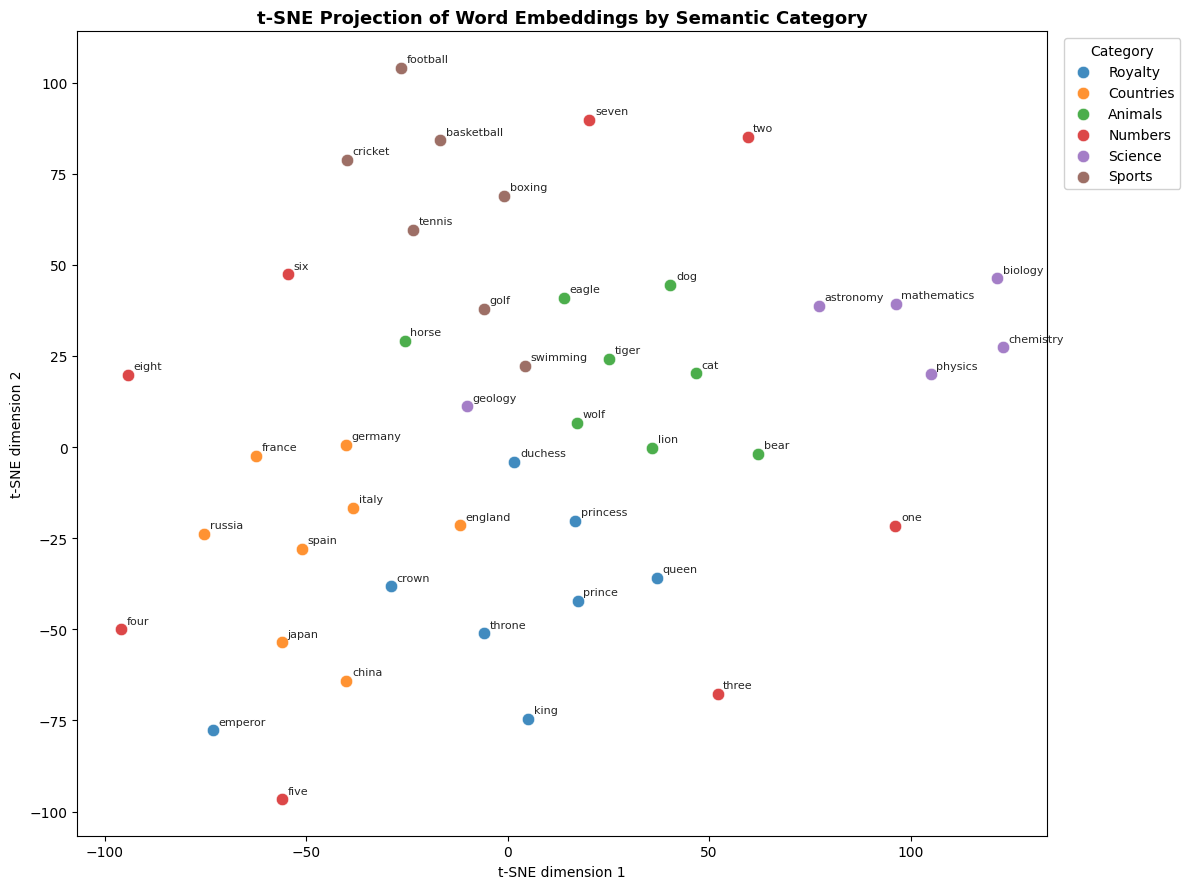

In [32]:
# Each group should be semantically related
WORD_GROUPS = {
    'Royalty'   : ['king', 'queen', 'prince', 'princess', 'throne', 'crown', 'emperor', 'duchess'],
    'Countries' : ['france', 'germany', 'england', 'italy', 'spain', 'russia', 'china','japan'],
    'Animals'   : ['dog', 'cat', 'horse', 'lion', 'tiger', 'bear', 'wolf', 'eagle'],
    'Numbers'   : ['one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight'],
    'Science'   : ['physics', 'chemistry', 'biology', 'mathematics', 'astronomy', 'geology'],
    'Sports'    : ['football', 'tennis', 'basketball', 'cricket', 'swimming', 'boxing', 'golf'],
}

# Filter to words actually in vocabulary
filtered_groups = {}
for group, words in WORD_GROUPS.items():
    present = [w for w in words if w in skipgram.vocab.word2idx]
    if len(present) >= 3:
        filtered_groups[group] = present

all_words  = [w for words in filtered_groups.values() for w in words]
all_labels = [g for g, words in filtered_groups.items() for _ in words]
all_vecs   = np.array([skipgram.get_embedding(w) for w in all_words])

tsne = TSNE(n_components=2, perplexity=min(15, len(all_words) - 1), random_state=21)
coords = tsne.fit_transform(all_vecs)

palette = sns.color_palette('tab10', n_colors=len(filtered_groups))
group_color = {g: palette[i] for i, g in enumerate(filtered_groups)}

fig, ax = plt.subplots(figsize=(12, 9))
for group, words in filtered_groups.items():
    mask = [i for i, l in enumerate(all_labels) if l == group]
    ax.scatter(coords[mask, 0], coords[mask, 1],
               color=group_color[group], s=80, alpha=0.85,
               edgecolors='white', linewidths=0.5, label=group, zorder=3)

for i, word in enumerate(all_words):
    ax.annotate(word, (coords[i, 0], coords[i, 1]),
                fontsize=8, alpha=0.85,
                xytext=(4, 4), textcoords='offset points')

ax.legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left', framealpha=0.9)
ax.set_title('t-SNE Projection of Word Embeddings by Semantic Category',
             fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE dimension 1')
ax.set_ylabel('t-SNE dimension 2')
plt.tight_layout()
plt.show()

## 1.3 Analogy Geometry

In [10]:
def solve_analogy(model, a, b, c, top_n=5):
    """
    Solve analogy: a is to b as c is to ?
    target = b - a + c
    Args:
        model: word2vec model
        a: vector a
        b: vector b
        c: vector c
        top_n: number of top words to return

    Returns:
         (target_vector, top_n results)
    """
    exclude = {a, b, c}
    va, vb, vc = (model.get_embedding(w) for w in (a, b, c))
    target = vb - va + vc
    target_norm = target / (np.linalg.norm(target) + 1e-10)

    all_vecs  = model.model.W_in
    norms     = np.linalg.norm(all_vecs, axis=1, keepdims=True) + 1e-10
    sims      = all_vecs / norms @ target_norm
    top_idx   = np.argsort(sims)[::-1]

    results = []
    for idx in top_idx:
        w = model.vocab.idx_to_word(idx)
        if w not in exclude and w != '<UNK>':
            results.append((w, float(sims[idx])))
        if len(results) == top_n:
            break
    return target, results


ANALOGIES = [
    ('man',    'king',    'woman'),    # → queen
    ('paris',  'france',  'berlin'),   # → germany
    ('slow',   'slower',  'fast'),     # → faster
]

valid_analogies = [(a, b, c) for a, b, c in ANALOGIES
                   if all(w in skipgram.vocab.word2idx for w in (a, b, c))]

for a, b, c in valid_analogies:
    _, results = solve_analogy(skipgram, a, b, c)
    answer = results[0][0] if results else '?'
    print(f'{a} → {b}  |  {c} → {answer}   (top-5: {[r[0] for r in results]})')

NameError: name 'skipgram' is not defined

## 1.4 SimLex999 Correlation

In [36]:
human_scores, model_scores, pair_labels = [], [], []

with open('../data/SimLex-999.txt', 'r', encoding='utf-8') as f:
    next(f)  # skip header
    for line in f:
        parts = line.strip().split('\t')
        w1, w2, score = parts[0], parts[1], float(parts[3])
        if w1 in skipgram.vocab.word2idx and w2 in skipgram.vocab.word2idx:
            sim = cosine_similarity(skipgram.get_embedding(w1), skipgram.get_embedding(w2))
            human_scores.append(score)
            model_scores.append(sim)
            pair_labels.append(f'{w1} / {w2}')

rho, pval = spearmanr(human_scores, model_scores)
coverage  = len(human_scores)
print(f'Pairs covered : {coverage} / 999')
print(f'Spearman rho  : {rho:.4f}  (p = {pval:.2e})')

Pairs covered : 955 / 999
Spearman rho  : 0.2122  (p = 3.52e-11)


# 2. CBOW

In [2]:
cbow = Word2Vec.load_model('../models/cbow-model.pkl')

## 2.1 Most Similar

In [3]:
cbow.most_similar('king')

[('hezekiah', np.float64(0.733843973436669)),
 ('hadad', np.float64(0.7168978661065655)),
 ('tyre', np.float64(0.7149024446150448)),
 ('kings', np.float64(0.7092266449610439)),
 ('jehoram', np.float64(0.7067965142613575)),
 ('son', np.float64(0.7025255476246487)),
 ('judah', np.float64(0.6964019780405707)),
 ('macedon', np.float64(0.6959747853370599)),
 ('pippin', np.float64(0.6853963249097137)),
 ('burgundy', np.float64(0.6819243353926108))]

In [4]:
cbow.most_similar('germany')

[('ceded', np.float64(0.7145053247134823)),
 ('netherlands', np.float64(0.6891382456943573)),
 ('italy', np.float64(0.6888652451787244)),
 ('switzerland', np.float64(0.6862069566049723)),
 ('austria', np.float64(0.6758384684672728)),
 ('ussr', np.float64(0.664396934644836)),
 ('reunification', np.float64(0.6635637892732598)),
 ('yugoslav', np.float64(0.6630078491335704)),
 ('pact', np.float64(0.6599916410765414)),
 ('czechoslovakia', np.float64(0.6595543024472367))]

In [5]:
cbow.most_similar('war')

[('iraqi', np.float64(0.6188051819526961)),
 ('expeditionary', np.float64(0.6025607230492178)),
 ('invaded', np.float64(0.5998864747395796)),
 ('allies', np.float64(0.5987087823905177)),
 ('wars', np.float64(0.5966030013745321)),
 ('loyal', np.float64(0.5947892409262789)),
 ('kuwait', np.float64(0.5900523153374008)),
 ('vietnamese', np.float64(0.5897009413156675)),
 ('formidable', np.float64(0.5846297595825423)),
 ('vietnam', np.float64(0.5799847532283344))]

In [6]:
cbow.most_similar('science')

[('cognitive', np.float64(0.7341545589267845)),
 ('mathematics', np.float64(0.733498721710099)),
 ('sciences', np.float64(0.7013723584821039)),
 ('psychology', np.float64(0.6835233690042253)),
 ('cambridge', np.float64(0.6687383908700351)),
 ('fiction', np.float64(0.6586226090458509)),
 ('id', np.float64(0.6533705747495697)),
 ('philosophy', np.float64(0.6512442880835383)),
 ('disciplines', np.float64(0.6498541712857737)),
 ('mit', np.float64(0.6465674819575291))]

## 2.2 t-SNE Semantic Cluster


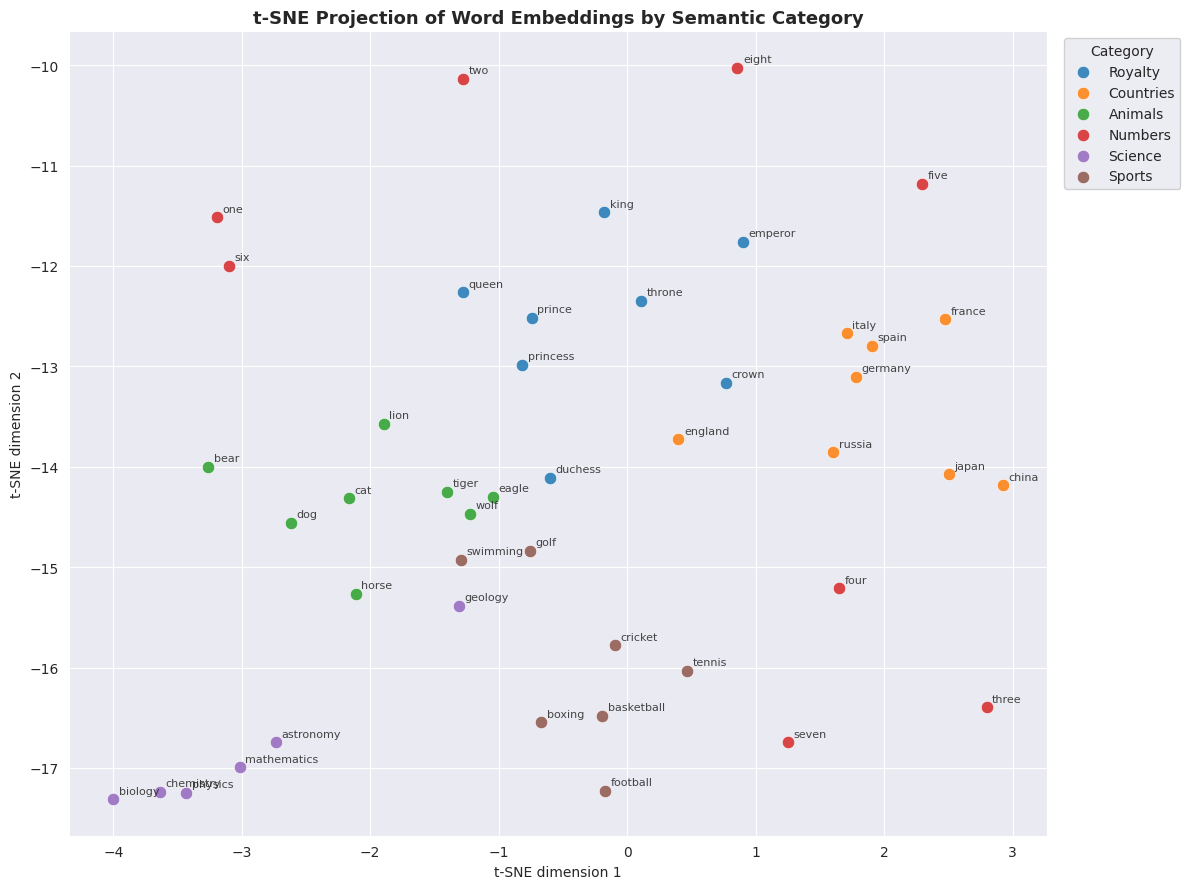

In [7]:
# Each group should be semantically related
WORD_GROUPS = {
    'Royalty'   : ['king', 'queen', 'prince', 'princess', 'throne', 'crown', 'emperor', 'duchess'],
    'Countries' : ['france', 'germany', 'england', 'italy', 'spain', 'russia', 'china','japan'],
    'Animals'   : ['dog', 'cat', 'horse', 'lion', 'tiger', 'bear', 'wolf', 'eagle'],
    'Numbers'   : ['one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight'],
    'Science'   : ['physics', 'chemistry', 'biology', 'mathematics', 'astronomy', 'geology'],
    'Sports'    : ['football', 'tennis', 'basketball', 'cricket', 'swimming', 'boxing', 'golf'],
}

# Filter to words actually in vocabulary
filtered_groups = {}
for group, words in WORD_GROUPS.items():
    present = [w for w in words if w in cbow.vocab.word2idx]
    if len(present) >= 3:
        filtered_groups[group] = present

all_words  = [w for words in filtered_groups.values() for w in words]
all_labels = [g for g, words in filtered_groups.items() for _ in words]
all_vecs   = np.array([cbow.get_embedding(w) for w in all_words])

tsne = TSNE(n_components=2, perplexity=min(15, len(all_words) - 1), random_state=21)
coords = tsne.fit_transform(all_vecs)

palette = sns.color_palette('tab10', n_colors=len(filtered_groups))
group_color = {g: palette[i] for i, g in enumerate(filtered_groups)}

fig, ax = plt.subplots(figsize=(12, 9))
for group, words in filtered_groups.items():
    mask = [i for i, l in enumerate(all_labels) if l == group]
    ax.scatter(coords[mask, 0], coords[mask, 1],
               color=group_color[group], s=80, alpha=0.85,
               edgecolors='white', linewidths=0.5, label=group, zorder=3)

for i, word in enumerate(all_words):
    ax.annotate(word, (coords[i, 0], coords[i, 1]),
                fontsize=8, alpha=0.85,
                xytext=(4, 4), textcoords='offset points')

ax.legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left', framealpha=0.9)
ax.set_title('t-SNE Projection of Word Embeddings by Semantic Category',
             fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE dimension 1')
ax.set_ylabel('t-SNE dimension 2')
plt.tight_layout()
plt.show()

## 2.3 Analogy Geometry

In [11]:
valid_analogies = [(a, b, c) for a, b, c in ANALOGIES
                   if all(w in cbow.vocab.word2idx for w in (a, b, c))]

for a, b, c in valid_analogies:
    _, results = solve_analogy(cbow, a, b, c)
    answer = results[0][0] if results else '?'
    print(f'{a} → {b}  |  {c} → {answer}   (top-5: {[r[0] for r in results]})')

man → king  |  woman → eldest   (top-5: ['eldest', 'sons', 'son', 'hezekiah', 'burgundy'])
paris → france  |  berlin → occupying   (top-5: ['occupying', 'mauritius', 'northeastern', 'outlying', 'forts'])
slow → slower  |  fast → iie   (top-5: ['iie', 'monochrome', 'agp', 'connector', 'cpus'])


## 2.4 SimLex999 Correlation

In [12]:
human_scores, model_scores, pair_labels = [], [], []

with open('../data/SimLex-999.txt', 'r', encoding='utf-8') as f:
    next(f)  # skip header
    for line in f:
        parts = line.strip().split('\t')
        w1, w2, score = parts[0], parts[1], float(parts[3])
        if w1 in cbow.vocab.word2idx and w2 in cbow.vocab.word2idx:
            sim = cosine_similarity(cbow.get_embedding(w1), cbow.get_embedding(w2))
            human_scores.append(score)
            model_scores.append(sim)
            pair_labels.append(f'{w1} / {w2}')

rho, pval = spearmanr(human_scores, model_scores)
coverage  = len(human_scores)
print(f'Pairs covered : {coverage} / 999')
print(f'Spearman rho  : {rho:.4f}  (p = {pval:.2e})')

Pairs covered : 955 / 999
Spearman rho  : 0.2217  (p = 4.28e-12)
